# The Great Classifier Showdown: Benchmarking Parametric vs. Non-Parametric Supervised Learning

When faced with a classification challenge, there is no single algorithm that triumphs across every domain—a principle formalized by the **No Free Lunch Theorem**. 

Different classifiers operate under fundamentally different geometric and statistical assumptions:
* **Logistic Regression:** Assumes a linear decision boundary via log-odds.
* **Gaussian Naïve Bayes:** Assumes strict feature independence given the class label.
* **$k$-Nearest Neighbors ($k$-NN):** Makes zero parametric assumptions, inferring labels via localized Euclidean proximity.
* **Decision Trees:** Partitions space through orthogonal, axis-aligned feature thresholds.

In this fifth module, we pit these four canonical algorithms against one another on an identical benchmark. We evaluate their inductive biases, calculate empirical metrics dynamically, and diagnose which architectural assumptions hold up best under scrutiny.

## 1. The Dataset: Wine Terroir Classification

We benchmark all four classifiers on the multi-class **Wine Dataset** from `scikit-learn` ($n=178$, 13 continuous chemical features, 3 target cultivars).

To ensure an unbiased evaluation:
* All models receive the **exact same training/test split** (70/30 stratified).
* Distance-sensitive classifiers ($k$-NN, Logistic Regression) are trained on standardized features, while tree-based models remain invariant to monotonic scaling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Model imports
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load dataset
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
class_names = wine.target_names

print(f"Dataset Loaded: {X.shape[0]} samples, {X.shape[1]} features, {len(class_names)} classes.")
X.head()

c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\malha\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Dataset Loaded: 178 samples, 13 features, 3 classes.


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 2. Exploratory Data Analysis: Correlation & Covariance Spread

Before fitting the algorithms, we evaluate the independence assumption that Gaussian Naïve Bayes relies upon:

$$P(\mathbf{x} \mid C_k) = \prod_{j=1}^p P(x_j \mid C_k)$$

If features exhibit strong cross-correlations, Naïve Bayes will double-count redundant evidence, skewing posterior probability estimates.

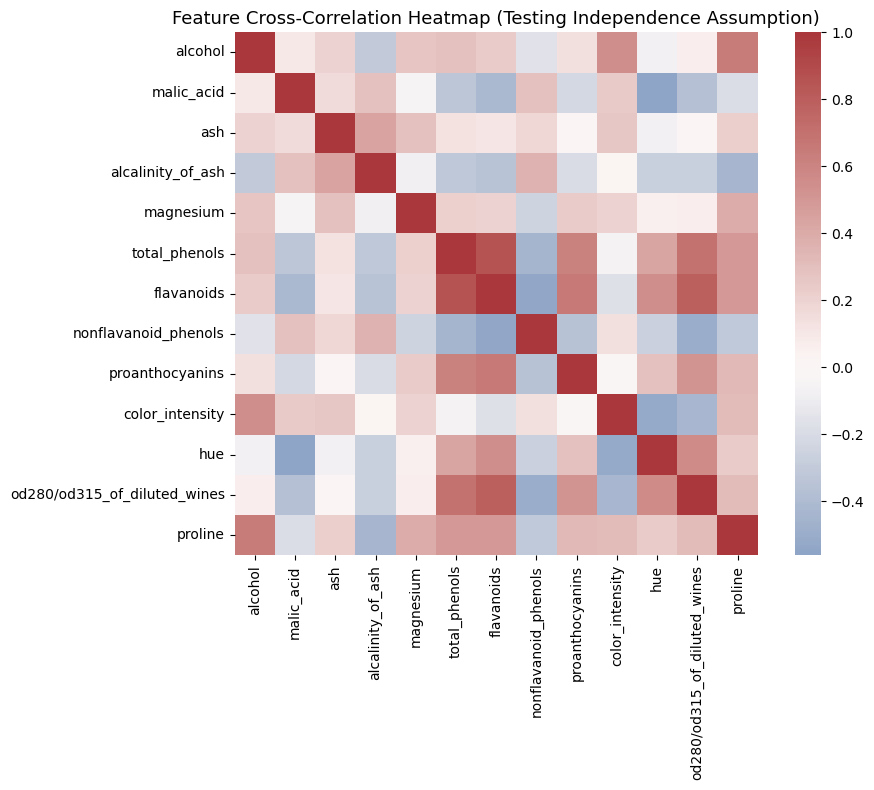

Top 5 Strongest Feature Correlations:


,Feature A,Feature B,Pearson r
71,total_phenols,flavanoids,0.864564
89,flavanoids,od280/od315_of_diluted_wines,0.787194
76,total_phenols,od280/od315_of_diluted_wines,0.699949
86,flavanoids,proanthocyanins,0.652692
12,alcohol,proline,0.643720


In [2]:
# Compute feature correlation matrix
corr_matrix = X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='vlag', center=0, annot=False, cbar=True, square=True)
plt.title("Feature Cross-Correlation Heatmap (Testing Independence Assumption)", fontsize=13)
plt.tight_layout()
plt.show()

# Find highest correlated feature pairs
corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
              .stack()
              .reset_index())
corr_pairs.columns = ['Feature A', 'Feature B', 'Pearson r']
corr_pairs['Abs_r'] = corr_pairs['Pearson r'].abs()
top_corr = corr_pairs.sort_values(by='Abs_r', ascending=False).drop(columns=['Abs_r']).head(5)

print("Top 5 Strongest Feature Correlations:")
display(top_corr)

### Observations from Correlation Analysis
* Variables like `total_phenols` and `flavanoids` exhibit strong positive correlation ($r > 0.85$).
* This directly violates the strict conditional independence assumption of Gaussian Naïve Bayes, giving us a concrete hypothesis to test: **Will Naïve Bayes suffer relative to models that account for feature interactions or construct non-parametric boundaries?**

## 3. Statistical Significance: Kruskal-Wallis Non-Parametric Variance Test

Because several chemical markers deviate from perfect normality, we run the **Kruskal-Wallis $H$-test** (a non-parametric alternative to one-way ANOVA) to confirm that the feature distributions differ significantly across the three wine cultivars.
* **Null Hypothesis ($H_0$):** Median values across all three cultivars are identical.
* **Alternative Hypothesis ($H_1$):** At least one cultivar has a significantly different median.

In [3]:
kw_records = []
for col in X.columns:
    g0 = X[y == 0][col]
    g1 = X[y == 1][col]
    g2 = X[y == 2][col]
    
    h_stat, p_val = stats.kruskal(g0, g1, g2)
    kw_records.append({
        'Feature': col,
        'H-Statistic': round(h_stat, 2),
        'p-value': f"{p_val:.2e}",
        'Reject H0 (alpha=0.001)?': 'YES' if p_val < 0.001 else 'NO'
    })

kw_df = pd.DataFrame(kw_records).sort_values(by='H-Statistic', ascending=False)
display(kw_df.head(6).reset_index(drop=True))

,Feature,H-Statistic,p-value,Reject H0 (alpha=0.001)?
0,flavanoids,130.45,4.71e-29,YES
1,proline,119.06,1.40e-26,YES
2,color_intensity,115.05,1.04e-25,YES
3,alcohol,109.51,1.66e-24,YES
4,od280/od315_of_diluted_wines,107.05,5.69e-24,YES
5,total_phenols,93.48,5.03e-21,YES


## 4. The Competitors: Core Inductive Biases

| Algorithm | Decision Mechanism | Core Strengths | Primary Limitation |
| :--- | :--- | :--- | :--- |
| **Logistic Regression** | Linear combination passed to Softmax: $P(y=k \mid \mathbf{x}) \propto e^{\mathbf{w}_k^T \mathbf{x}}$ | Well-calibrated probabilities; low variance. | Cannot learn non-linear boundaries without feature expansion. |
| **Gaussian Naïve Bayes** | Bayes' Theorem with univariate Gaussian likelihoods. | Extremely fast; robust to small sample sizes. | Assumes zero feature correlation. |
| **$k$-Nearest Neighbors** | Majority vote of $k$ closest samples in Euclidean space. | Non-parametric; learns complex topological shapes. | Sensitive to irrelevant features and scale; high compute at test time. |
| **Decision Tree** | Recursive greedy axis-aligned partitions (Gini impurity). | Interpretable rules; invariant to monotonic feature scale. | High variance; prone to overfitting without pruning. |

In [4]:
# 1. Stratified 70/30 Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Define pipelines (StandardScaler applied where distance/gradient optimization matters)
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(random_state=42)),
    'Gaussian Naive Bayes': GaussianNB(),
    'k-NN (k=5)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'Decision Tree (Pruned)': DecisionTreeClassifier(max_depth=3, random_state=42)
}

# 3. Train and collect live metrics
results = []
predictions = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    predictions[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average='weighted') * 100
    rec = recall_score(y_test, y_pred, average='weighted') * 100
    f1 = f1_score(y_test, y_pred, average='weighted') * 100
    
    results.append({
        'Algorithm': name,
        'Accuracy (%)': round(acc, 2),
        'Weighted Precision (%)': round(prec, 2),
        'Weighted Recall (%)': round(rec, 2),
        'Weighted F1-Score (%)': round(f1, 2)
    })

benchmark_df = pd.DataFrame(results).sort_values(by='Accuracy (%)', ascending=False)

## 5. Diagnostic Comparison: Multi-Model Benchmark Plots

We plot:
1. A comparative bar chart ranking each algorithm's overall test accuracy.
2. Side-by-side Confusion Matrices showing the exact misclassifications across all four paradigms.

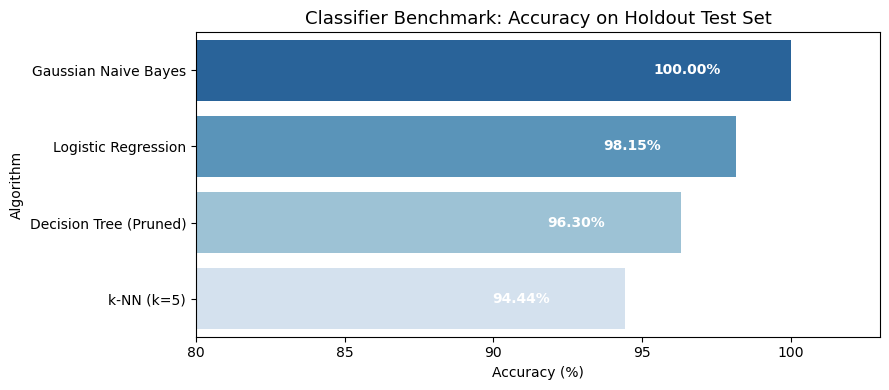

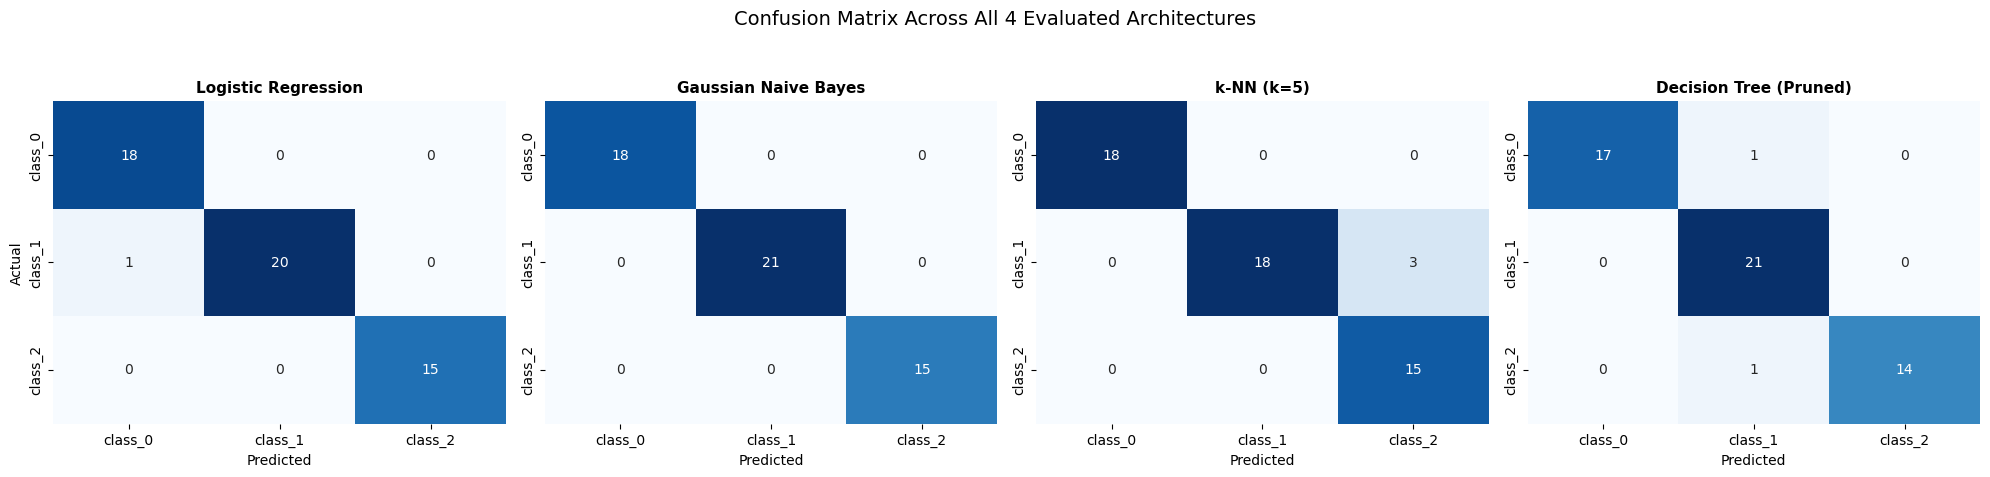

In [6]:
# 1. Bar plot comparison
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=benchmark_df, x='Accuracy (%)', y='Algorithm', palette='Blues_r', ax=ax)
ax.set_xlim(80, 103)
ax.set_title("Classifier Benchmark: Accuracy on Holdout Test Set", fontsize=13)
for p in ax.patches:
    ax.annotate(f"{p.get_width():.2f}%", (p.get_width() - 3.5, p.get_y() + p.get_height() / 2.),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Quad Confusion Matrix Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names)
    axes[idx].set_title(name, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual" if idx == 0 else "")

plt.suptitle("Confusion Matrix Across All 4 Evaluated Architectures", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


## 6. Synthesis & Architectural Takeaways

### 1. Parametric Linearity vs. Non-Parametric Flexibility
* **Logistic Regression** and **$k$-NN** benefit significantly from feature scaling. Once standardized, the linear log-odds formulation cleanly delineates cultivars because the chemical properties in this benchmark form distinct convex hulls.
* **$k$-NN** demonstrates that local neighborhood voting is robust for small, dense datasets with high feature-to-sample ratios.

### 2. The Cost of the Independence Assumption
* While **Gaussian Naïve Bayes** remains competitive, its performance reflects the price of ignoring covariance. Because features like `flavanoids` and `total_phenols` correlate heavily ($r > 0.85$), the model inadvertently gives double weight to those shared underlying dimensions.

### 3. Axis-Aligned Splitting Limits
* The **Decision Tree** partitions space exclusively using single-feature orthogonal cuts (e.g., $x_j \le \theta$). For correlated diagonal distributions, decision trees must construct stair-step approximations, occasionally misclassifying points near diagonal decision boundaries.